# Cars4You - Handout Project | Group 42
## Halving Random Search Notebook
**Course:** MSc in Data Science and Advanced Analytics, NOVA IMS (2025/2026)  

**Author(s):** Group 42
- `Miguel Matos - 20221925`
- `Andre Nicolau - 20221918`
- `André Ferreira - 20250398`


---

#### <font> Table of Contents </font> <a class="anchor" id='toc'></a> 
1. [Imports](#Imports)  
2. [Modelling Testing](#modelling-testing) 
----

After completing our exploratory data analysis and data cleaning, we moved on to the preprocessing steps. Because we are using a custom pipeline (Nuestra_Pipeline) to train our models with cross-validation and perform hyperparameter tuning, we built an individual custom class for each preprocessing step (inside Preprocessing_pipelines). Each class includes custom strategies that handle specific preprocessing tasks. This design allows us to include preprocessing choices as hyperparameters in our search grid when looking for the best model.

This notebook is the first step in our search process. Here, we use HalvingRandomSearchCV, a hyperparameter-tuning technique that begins by training a large number of candidate models using small amounts of data. After the initial evaluation, only the best candidates are trained on larger datasets in subsequent rounds. We chose this method as our initial search strategy because it allows us to explore a broader hyperparameter space than a regular RandomizedSearchCV while being computationally cheaper. Once we identify the region of the hyperparameter space that yields the best scores, we plan to run Bayes searches around those values to find the true best model.

# Imports
[Back to TOC](#toc)

In [ ]:
from utils.functions import *
from scipy.stats import randint
from sklearn.svm import LinearSVR
from utils.Nuestra_Pipeline import NuestraPipeline
from Preprocessing_pipelines.Outliers_pipeline import OutliersDealer
from Preprocessing_pipelines.Missing_Values_pipeline import MissingValuesDealer
from Preprocessing_pipelines.Encoding_pipeline import EncodingDealer
from Preprocessing_pipelines.Scaling_pipeline import ScalingDealer
from Preprocessing_pipelines.Feature_Selection_pipeline import FeatureSelectionDealer
import warnings

# Suppress this specific warning
warnings.filterwarnings('ignore', 
                       message='X does not have valid feature names',
                       category=UserWarning,
                       module='sklearn.utils.validation')



data = pd.read_csv("data/data_cleaned.csv", index_col= "carID")
pd.set_option("display.max_columns", None)

In [2]:
data = data.sample(frac=1).reset_index(drop=True)

As the objective is to create a predictive model that is accurate without the need of the mechanic's assessment, we'll drop the "paintQuality%" column.

In [3]:
data.drop("paintQuality%", axis = 1, inplace= True)

In [4]:
X = data.drop("price", axis= 1)
y = data["price"]

# Halving Random Search for Preprocess Parameters Tuning

Our first goal is to identify the best combination of preprocessing parameters to use when training each models. To do this, we perform a Halving Random Search for each model using a set of standard parameters. We didn't use default model parameters because, for some models, the defaults can lead to severe overfitting, so we adjusted them beforehand.
We found 200 as number of candidates, factor of 2, cv of 3 and 2000 minimum resources to be resonable options for the parameters of our Halving Random Seach runs as they explore a good space of options and they didn't take to long to run

(Note: We could include the preprocessing parameters directly in the hyperparameter search when tuning the models. However, we found this approach to be extremely computationally expensive. Therefore, we decided to first find a good preprocessing configuration and then proceed to the model-tuning stage.)

### Random Forest

In [22]:
rf = RandomForestRegressor(
    n_estimators=100,          # Reduced from 150 for faster training
    max_depth=12,              
    min_samples_split=10,      # Increased to reduce tree complexity
    min_samples_leaf=4,        # Increased to reduce overfitting and speed up
    max_features="sqrt",              
    random_state=42
)

parameters = {
              "imputer__imputation_method": ["knn_modelwise", "simple", "iterative"],
              "imputer__knn_neighbors": np.arange(5,21),
              "imputer__knn_scaling_method" : ["standard", "minmax", "robust"],
              "outlier_remover__outlier_method" : ["Isolation_Forest", "LOF", "IQR", "z_score"],
              "outlier_remover__mod_outliers_cols" : [["car_age", "mileage", "tax", "mpg"], ["tax", "mpg"]],
              "outlier_remover__sev_outliers_cols" : [["car_age", "mileage", "engineSize"], ["car_age", "mileage"]],
              "outlier_remover__threshold" : [2,3],
              "outlier_remover__z_columns" : [["car_age", "mileage", "tax", "mpg"]],
              "outlier_remover__contamination_IF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__n_neighbors": [30, 50, 70, 90, 100],
              "outlier_remover__contamination_LOF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__model_columns" : [["tax", "mpg"], ["car_age", "mileage", "tax", "mpg"], ["car_age", "mileage", "tax", "mpg", "engineSize"]],
              "encoder__method" : ["target", "freq"],
              "scaler__scaler_name" : ["robust", "minmax", "standard"],
              "selector__selection_method": ["kbest", "model", "rfe"],
              "selector__k": np.arange(5,11),
              "selector__model_name" : ["rf"],
              "selector__n_features_to_select": np.arange(5,11),
              "model": [rf]
    }

pipeline = NuestraPipeline(MissingValuesDealer(),
                           OutliersDealer(),
                           EncodingDealer(), 
                           ScalingDealer(),
                           FeatureSelectionDealer(),
                           rf)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_parameters_rf = HalvingRandomSearchCV(
                                      pipeline, 
                                      parameters,
                                      n_candidates=200,      
                                      factor=2,    
                                      min_resources = 2000,         
                                      scoring=mae_scorer, 
                                      verbose=3, 
                                      cv=3,                 
                                      n_jobs= 4,            
                                      random_state=42)

In [23]:
HRS_parameters_rf.fit(X, y)

n_iterations: 6
n_required_iterations: 8
n_possible_iterations: 6
min_resources_: 2000
max_resources_: 75973
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 200
n_resources: 2000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 100
n_resources: 4000
Fitting 3 folds for each of 100 candidates, totalling 300 fits
----------
iter: 2
n_candidates: 50
n_resources: 8000
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 3
n_candidates: 25
n_resources: 16000
Fitting 3 folds for each of 25 candidates, totalling 75 fits
----------
iter: 4
n_candidates: 13
n_resources: 32000
Fitting 3 folds for each of 13 candidates, totalling 39 fits
----------
iter: 5
n_candidates: 7
n_resources: 64000
Fitting 3 folds for each of 7 candidates, totalling 21 fits


,estimator,NuestraPipeli...ctionDealer())
,param_distributions,"{'encoder__method': ['target', 'freq'], 'imputer__imputation_method': ['knn_modelwise', 'simple', ...], 'imputer__knn_neighbors': array([ 5, 6..., 18, 19, 20]), 'imputer__knn_scaling_method': ['standard', 'minmax', ...], ...}"
,n_candidates,200
,factor,2
,resource,'n_samples'
,max_resources,'auto'
,min_resources,2000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In this cell we are getting and storing the results of the Halving Random search for future evaluation

In [ ]:
rf_params = pd.DataFrame(HRS_parameters_rf.cv_results_)
rf_params.to_csv("data/final_data/HRS_preproc/RF_params.csv")

joblib.dump(HRS_parameters_rf.best_estimator_, 'models/models_organized/models_preproc_tuning/rf_params.pkl')
rf_parameters = joblib.load('models/models_organized/models_preproc_tuning/rf_params.pkl')

rf_params.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__selection_method,param_selector__n_features_to_select,param_selector__model_name,param_selector__k,param_scaler__scaler_name,param_outlier_remover__z_columns,param_outlier_remover__threshold,param_outlier_remover__sev_outliers_cols,param_outlier_remover__outlier_method,param_outlier_remover__n_neighbors,param_outlier_remover__model_columns,param_outlier_remover__mod_outliers_cols,param_outlier_remover__contamination_LOF,param_outlier_remover__contamination_IF,param_model,param_imputer__knn_scaling_method,param_imputer__knn_neighbors,param_imputer__imputation_method,param_encoder__method,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
390,5,64000,47.438836,0.431526,3.105647,0.032486,model,9,rf,9,robust,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage]",IQR,50,"[car_age, mileage, tax, mpg]","[car_age, mileage, tax, mpg]",0.15,0.05,"RandomForestRegressor(max_depth=12, max_featur...",standard,6,knn_modelwise,target,"{'selector__selection_method': 'model', 'selec...",-1578.428848,-1596.168056,-1577.084982,-1583.893962,8.696418,6,-1413.964937,-1421.198755,-1425.192247,-1420.118646,4.646726
391,5,64000,12.195417,0.120863,2.948524,0.169288,kbest,5,rf,10,standard,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",z_score,100,"[car_age, mileage, tax, mpg, engineSize]","[tax, mpg]",0.50,0.50,"RandomForestRegressor(max_depth=12, max_featur...",robust,8,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1577.111568,-1582.377048,-1570.364466,-1576.617694,4.916534,2,-1415.556785,-1408.777461,-1419.305311,-1414.546519,4.356940
392,5,64000,47.900581,0.623138,3.249648,0.231413,rfe,10,rf,8,robust,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage]",z_score,50,"[tax, mpg]","[car_age, mileage, tax, mpg]",0.05,0.15,"RandomForestRegressor(max_depth=12, max_featur...",standard,8,knn_modelwise,target,"{'selector__selection_method': 'rfe', 'selecto...",-1581.880729,-1587.713134,-1573.080052,-1580.891305,6.014759,5,-1416.096408,-1414.483236,-1424.642792,-1418.407479,4.457946
393,5,64000,11.620932,0.813111,3.085826,0.240095,kbest,6,rf,10,robust,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",IQR,100,"[car_age, mileage, tax, mpg, engineSize]","[tax, mpg]",0.15,0.30,"RandomForestRegressor(max_depth=12, max_featur...",minmax,6,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1586.962737,-1581.162049,-1569.256676,-1579.127154,7.370289,3,-1423.086366,-1416.065334,-1419.031826,-1419.394509,2.877774
394,5,64000,42.643731,1.271451,2.308721,0.234863,model,8,rf,10,robust,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",z_score,100,"[car_age, mileage, tax, mpg]","[tax, mpg]",0.50,0.50,"RandomForestRegressor(max_depth=12, max_featur...",robust,13,knn_modelwise,target,"{'selector__selection_method': 'model', 'selec...",-1581.535398,-1578.792595,-1567.582394,-1575.970129,6.035800,1,-1418.850946,-1408.746604,-1416.035584,-1414.544378,4.257715


### Decision Tree

In [25]:
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,      # Increased for speed
    min_samples_leaf=4,        # Increased for speed
    max_features="sqrt",
    random_state=42
)

parameters = {
              "imputer__imputation_method": ["knn_modelwise", "simple", "iterative"],
              "imputer__knn_neighbors": np.arange(10,21),
              "imputer__knn_scaling_method" : ["standard", "minmax", "robust"],
              "outlier_remover__outlier_method" : ["Isolation_Forest", "LOF", "IQR", "z_score"],
              "outlier_remover__mod_outliers_cols" : [["car_age", "mileage", "tax", "mpg"], ["tax", "mpg"]],
              "outlier_remover__sev_outliers_cols" : [["car_age", "mileage", "engineSize"], ["car_age", "mileage"]],
              "outlier_remover__threshold" : [2,3],
              "outlier_remover__z_columns" : [["car_age", "mileage", "tax", "mpg"]],
              "outlier_remover__contamination_IF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__n_neighbors": [30, 50, 70, 90, 100],
              "outlier_remover__contamination_LOF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__model_columns" : [["tax", "mpg"], ["car_age", "mileage", "tax", "mpg"], ["car_age", "mileage", "tax", "mpg", "engineSize"]],
              "encoder__method" : ["target", "freq"],
              "scaler__scaler_name" : ["robust", "minmax", "standard"],
              "selector__selection_method": ["kbest", "model", "rfe"],
              "selector__k": np.arange(5,11),
              "selector__model_name" : ["dt"],
              "selector__n_features_to_select": np.arange(5,11),
              "model": [dt]
              }

pipeline = NuestraPipeline(MissingValuesDealer(),
                           OutliersDealer(),
                           EncodingDealer(), 
                           ScalingDealer(),
                           FeatureSelectionDealer(),
                           dt)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_parameters_dt = HalvingRandomSearchCV(
                                      pipeline, 
                                      parameters,
                                      n_candidates=200,      
                                      factor=2,    
                                      min_resources = 2000,         
                                      scoring=mae_scorer, 
                                      verbose=3, 
                                      cv=3,                 
                                      n_jobs= 4,            
                                      random_state=42)

In [21]:
HRS_parameters_dt.fit(X, y)

NameError: name 'HRS_parameters_dt' is not defined

In [ ]:
dt_params = pd.DataFrame(HRS_parameters_dt.cv_results_)
dt_params.to_csv("data/final_data/HRS_preproc/DT_params.csv")

joblib.dump(HRS_parameters_dt.best_estimator_, 'models/models_organized/models_preproc_tuning/dt_params.pkl')
dt_parameters = joblib.load('models/models_organized/models_preproc_tuning/dt_params.pkl')

dt_params.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__selection_method,param_selector__n_features_to_select,param_selector__model_name,param_selector__k,param_scaler__scaler_name,param_outlier_remover__z_columns,param_outlier_remover__threshold,param_outlier_remover__sev_outliers_cols,param_outlier_remover__outlier_method,param_outlier_remover__n_neighbors,param_outlier_remover__model_columns,param_outlier_remover__mod_outliers_cols,param_outlier_remover__contamination_LOF,param_outlier_remover__contamination_IF,param_model,param_imputer__knn_scaling_method,param_imputer__knn_neighbors,param_imputer__imputation_method,param_encoder__method,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
390,5,64000,3.035964,0.100397,0.067264,0.003082,rfe,6,dt,7,standard,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage]",IQR,100,"[car_age, mileage, tax, mpg, engineSize]","[tax, mpg]",0.15,0.30,"DecisionTreeRegressor(max_depth=10, max_featur...",robust,14,iterative,target,"{'selector__selection_method': 'rfe', 'selecto...",-2183.287813,-2170.523392,-2095.681036,-2149.830747,38.642602,8,-2021.535070,-2024.727323,-1968.995722,-2005.086038,25.552962
391,5,64000,3.055868,0.065999,0.074315,0.003402,rfe,6,dt,6,minmax,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage]",z_score,90,"[tax, mpg]","[car_age, mileage, tax, mpg]",0.50,0.30,"DecisionTreeRegressor(max_depth=10, max_featur...",minmax,12,iterative,target,"{'selector__selection_method': 'rfe', 'selecto...",-2106.073968,-2118.608977,-2157.317010,-2127.333318,21.810516,5,-1959.109986,-1962.210285,-2012.143989,-1977.821420,24.302703
392,5,64000,1.475465,0.098131,0.071799,0.001935,model,7,dt,9,robust,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",IQR,30,"[tax, mpg]","[tax, mpg]",0.30,0.50,"DecisionTreeRegressor(max_depth=10, max_featur...",robust,14,iterative,target,"{'selector__selection_method': 'model', 'selec...",-2134.700101,-2064.078695,-2052.701733,-2083.826843,36.271431,2,-1961.241060,-1917.987105,-1924.578815,-1934.602327,19.027686
393,5,64000,3.263310,0.065827,0.060892,0.008140,rfe,5,dt,7,standard,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",IQR,30,"[tax, mpg]","[tax, mpg]",0.15,0.15,"DecisionTreeRegressor(max_depth=10, max_featur...",standard,11,iterative,target,"{'selector__selection_method': 'rfe', 'selecto...",-2076.616903,-2073.968029,-2103.735381,-2084.773438,13.451657,3,-1930.858143,-1937.305108,-1953.826613,-1940.663288,9.672838
394,5,64000,0.853394,0.078308,0.070337,0.006624,kbest,9,dt,9,standard,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",z_score,70,"[car_age, mileage, tax, mpg, engineSize]","[tax, mpg]",0.15,0.50,"DecisionTreeRegressor(max_depth=10, max_featur...",minmax,14,iterative,target,"{'selector__selection_method': 'kbest', 'selec...",-2058.525311,-2029.977519,-2116.217284,-2068.240038,35.871123,1,-1916.183334,-1873.528870,-1976.555778,-1922.089327,42.267375


### Extra Trees

In [28]:
et = ExtraTreesRegressor(
    n_estimators=100,          # Reduced from 200 for speed with 75k rows
    max_depth=12,
    min_samples_split=10,      # Increased for speed
    min_samples_leaf=4,        # Increased for speed
    max_features="sqrt",
    bootstrap=False,
    n_jobs=-1,                 # Use all CPU cores
    random_state=42
)

parameters = {
              "imputer__imputation_method": ["knn_modelwise", "simple", "iterative"],
              "imputer__knn_neighbors": np.arange(10,21),
              "imputer__knn_scaling_method" : ["standard", "minmax", "robust"],
              "outlier_remover__outlier_method" : ["Isolation_Forest", "LOF", "IQR", "z_score"],
              "outlier_remover__mod_outliers_cols" : [["car_age", "mileage", "tax", "mpg"], ["tax", "mpg"]],
              "outlier_remover__sev_outliers_cols" : [["car_age", "mileage", "engineSize"], ["car_age", "mileage"]],
              "outlier_remover__threshold" : [2,3],
              "outlier_remover__z_columns" : [["car_age", "mileage", "tax", "mpg"]],
              "outlier_remover__contamination_IF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__n_neighbors": [30, 50, 70, 90, 100],
              "outlier_remover__contamination_LOF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__model_columns" : [["tax", "mpg"], ["car_age", "mileage", "tax", "mpg"], ["car_age", "mileage", "tax", "mpg", "engineSize"]],
              "encoder__method" : ["target", "freq"],
              "scaler__scaler_name" : ["robust", "minmax", "standard"],
              "selector__selection_method": ["kbest", "model", "rfe"],
              "selector__k": np.arange(5,11),
              "selector__model_name" : ["et"],
              "selector__n_features_to_select": np.arange(5,11),
              "model": [et]
              
    }

pipeline = NuestraPipeline(MissingValuesDealer(),
                           OutliersDealer(),
                           EncodingDealer(), 
                           ScalingDealer(),
                           FeatureSelectionDealer(),
                           et)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_parameters_et = HalvingRandomSearchCV(
                                      pipeline, 
                                      parameters,
                                      n_candidates=200,      
                                      factor=2,    
                                      min_resources = 2000,         
                                      scoring=mae_scorer, 
                                      verbose=3, 
                                      cv=3,                 
                                      n_jobs= 4,            
                                      random_state=42)

In [29]:
HRS_parameters_et.fit(X, y)

n_iterations: 6
n_required_iterations: 8
n_possible_iterations: 6
min_resources_: 2000
max_resources_: 75973
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 200
n_resources: 2000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 100
n_resources: 4000
Fitting 3 folds for each of 100 candidates, totalling 300 fits
----------
iter: 2
n_candidates: 50
n_resources: 8000
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 3
n_candidates: 25
n_resources: 16000
Fitting 3 folds for each of 25 candidates, totalling 75 fits
----------
iter: 4
n_candidates: 13
n_resources: 32000
Fitting 3 folds for each of 13 candidates, totalling 39 fits
----------
iter: 5
n_candidates: 7
n_resources: 64000
Fitting 3 folds for each of 7 candidates, totalling 21 fits


,estimator,NuestraPipeli...ctionDealer())
,param_distributions,"{'encoder__method': ['target', 'freq'], 'imputer__imputation_method': ['knn_modelwise', 'simple', ...], 'imputer__knn_neighbors': array([10, 11..., 18, 19, 20]), 'imputer__knn_scaling_method': ['standard', 'minmax', ...], ...}"
,n_candidates,200
,factor,2
,resource,'n_samples'
,max_resources,'auto'
,min_resources,2000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
et_params = pd.DataFrame(HRS_parameters_et.cv_results_)
et_params.to_csv("data/final_data/HRS_preproc/ET_params.csv")

joblib.dump(HRS_parameters_et.best_estimator_, 'models/models_organized/models_preproc_tuning/et_params.pkl')
et_parameters = joblib.load('models/models_organized/models_preproc_tuning/et_params.pkl')

et_params.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__selection_method,param_selector__n_features_to_select,param_selector__model_name,param_selector__k,param_scaler__scaler_name,param_outlier_remover__z_columns,param_outlier_remover__threshold,param_outlier_remover__sev_outliers_cols,param_outlier_remover__outlier_method,param_outlier_remover__n_neighbors,param_outlier_remover__model_columns,param_outlier_remover__mod_outliers_cols,param_outlier_remover__contamination_LOF,param_outlier_remover__contamination_IF,param_model,param_imputer__knn_scaling_method,param_imputer__knn_neighbors,param_imputer__imputation_method,param_encoder__method,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
390,5,64000,28.770882,1.720199,0.251062,0.083905,model,7,et,9,robust,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",IQR,30,"[tax, mpg]","[tax, mpg]",0.30,0.50,"ExtraTreesRegressor(max_depth=12, max_features...",robust,14,iterative,target,"{'selector__selection_method': 'model', 'selec...",-1981.367738,-1950.231437,-1948.586977,-1960.062051,15.080347,10,-1895.687076,-1881.012368,-1898.986482,-1891.895308,7.812397
391,5,64000,1.662834,0.181420,0.508298,0.253932,kbest,5,et,9,minmax,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage]",z_score,100,"[tax, mpg]","[car_age, mileage, tax, mpg]",0.15,0.05,"ExtraTreesRegressor(max_depth=12, max_features...",minmax,19,simple,target,"{'selector__selection_method': 'kbest', 'selec...",-1944.438704,-1919.830904,-1917.972068,-1927.413892,12.062255,4,-1857.586958,-1838.290332,-1858.351989,-1851.409760,9.282092
392,5,64000,1.703498,0.260421,0.247428,0.070207,kbest,8,et,9,standard,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",IQR,100,"[car_age, mileage, tax, mpg, engineSize]","[car_age, mileage, tax, mpg]",0.05,0.50,"ExtraTreesRegressor(max_depth=12, max_features...",minmax,10,simple,target,"{'selector__selection_method': 'kbest', 'selec...",-1936.686473,-1911.309037,-1895.125773,-1914.373761,17.104918,1,-1848.401553,-1838.305100,-1841.209472,-1842.638708,4.243947
393,5,64000,2.630156,0.106230,0.241697,0.062896,kbest,9,et,9,standard,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",z_score,70,"[car_age, mileage, tax, mpg, engineSize]","[tax, mpg]",0.15,0.50,"ExtraTreesRegressor(max_depth=12, max_features...",minmax,14,iterative,target,"{'selector__selection_method': 'kbest', 'selec...",-1928.888683,-1928.256469,-1901.735131,-1919.626761,12.653925,3,-1839.981285,-1851.254118,-1845.481009,-1845.572137,4.602566
394,5,64000,42.258458,0.371245,0.360745,0.102663,rfe,9,et,5,standard,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",IQR,70,"[car_age, mileage, tax, mpg, engineSize]","[car_age, mileage, tax, mpg]",0.50,0.15,"ExtraTreesRegressor(max_depth=12, max_features...",robust,19,iterative,target,"{'selector__selection_method': 'rfe', 'selecto...",-1939.057812,-1920.598553,-1889.233510,-1916.296625,20.566886,2,-1848.472443,-1850.041132,-1834.282428,-1844.265334,7.087971


### Hist Gradient Boosting

In [7]:
hgb = HistGradientBoostingRegressor(
    max_iter=100,              
    max_depth=5,               
    learning_rate=0.1,         
    min_samples_leaf=20,       
    max_leaf_nodes=31,         # Controls complexity (2^5 - 1)
    l2_regularization=0.0,     
    random_state=42
)

parameters = {
               "imputer__imputation_method": ["knn_modelwise", "simple", "iterative"],
               "imputer__knn_neighbors": np.arange(10, 21),
               "imputer__knn_scaling_method": ["standard", "minmax", "robust"],
               "outlier_remover__outlier_method": ["Isolation_Forest", "LOF", "IQR", "z_score"],
               "outlier_remover__mod_outliers_cols": [["car_age", "mileage", "tax", "mpg"], ["tax", "mpg"]],
               "outlier_remover__sev_outliers_cols": [["car_age", "mileage", "engineSize"], ["car_age", "mileage"]],
               "outlier_remover__threshold": [2, 3],
               "outlier_remover__z_columns": [["car_age", "mileage", "tax", "mpg"]],
               "outlier_remover__contamination_IF": [0.05, 0.15, 0.3, 0.5],
               "outlier_remover__n_neighbors": [30, 50, 70, 90, 100],
               "outlier_remover__contamination_LOF": [0.05, 0.15, 0.3, 0.5],
               "outlier_remover__model_columns": [["tax", "mpg"], ["car_age", "mileage", "tax", "mpg"], ["car_age", "mileage", "tax", "mpg", "engineSize"]],
               "encoder__method": ["target", "freq"],  
               "scaler__scaler_name": ["robust", "minmax", "standard"],
               "selector__selection_method": ["kbest"],
               "selector__k": np.arange(5,11),
               "selector__model_name": ["hgb"],
               "selector__n_features_to_select": np.arange(5,11),
               "model": [hgb]
}

pipeline = NuestraPipeline(MissingValuesDealer(),
                           OutliersDealer(),
                           EncodingDealer(), 
                           ScalingDealer(),
                           FeatureSelectionDealer(),
                           hgb)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_parameters_hgb = HalvingRandomSearchCV(
                                      pipeline, 
                                      parameters,
                                      n_candidates=200,      
                                      factor=2,    
                                      min_resources = 2000,         
                                      scoring=mae_scorer, 
                                      verbose=3, 
                                      cv=3,                 
                                      n_jobs= 4,            
                                      random_state=42)

In [8]:
HRS_parameters_hgb.fit(X, y)

n_iterations: 6
n_required_iterations: 8
n_possible_iterations: 6
min_resources_: 2000
max_resources_: 75973
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 200
n_resources: 2000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 100
n_resources: 4000
Fitting 3 folds for each of 100 candidates, totalling 300 fits
----------
iter: 2
n_candidates: 50
n_resources: 8000
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 3
n_candidates: 25
n_resources: 16000
Fitting 3 folds for each of 25 candidates, totalling 75 fits
----------
iter: 4
n_candidates: 13
n_resources: 32000
Fitting 3 folds for each of 13 candidates, totalling 39 fits
----------
iter: 5
n_candidates: 7
n_resources: 64000
Fitting 3 folds for each of 7 candidates, totalling 21 fits


,estimator,NuestraPipeli...ctionDealer())
,param_distributions,"{'encoder__method': ['target', 'freq'], 'imputer__imputation_method': ['knn_modelwise', 'simple', ...], 'imputer__knn_neighbors': array([10, 11..., 18, 19, 20]), 'imputer__knn_scaling_method': ['standard', 'minmax', ...], ...}"
,n_candidates,200
,factor,2
,resource,'n_samples'
,max_resources,'auto'
,min_resources,2000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
hgb_params = pd.DataFrame(HRS_parameters_hgb.cv_results_)
hgb_params.to_csv("data/final_data/HRS_preproc/HGB_params.csv")

joblib.dump(HRS_parameters_hgb.best_estimator_, 'models/models_organized/models_preproc_tuning/hgb_params.pkl')
hgb_parameters = joblib.load('models/models_organized/models_preproc_tuning/hgb_params.pkl')

hgb_params.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__selection_method,param_selector__n_features_to_select,param_selector__model_name,param_selector__k,param_scaler__scaler_name,param_outlier_remover__z_columns,param_outlier_remover__threshold,param_outlier_remover__sev_outliers_cols,param_outlier_remover__outlier_method,param_outlier_remover__n_neighbors,param_outlier_remover__model_columns,param_outlier_remover__mod_outliers_cols,param_outlier_remover__contamination_LOF,param_outlier_remover__contamination_IF,param_model,param_imputer__knn_scaling_method,param_imputer__knn_neighbors,param_imputer__imputation_method,param_encoder__method,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
390,5,64000,6.004169,0.290761,2.693481,0.081053,kbest,5,hgb,9,robust,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage]",IQR,70,"[car_age, mileage, tax, mpg]","[car_age, mileage, tax, mpg]",0.05,0.05,"HistGradientBoostingRegressor(max_depth=5, ran...",minmax,11,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1674.950858,-1707.834980,-1694.972321,-1692.586053,13.530511,5,-1627.653533,-1623.510586,-1620.252906,-1623.805675,3.028490
391,5,64000,5.551091,0.123867,2.655118,0.033841,kbest,6,hgb,10,minmax,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage]",IQR,100,"[tax, mpg]","[car_age, mileage, tax, mpg]",0.05,0.30,"HistGradientBoostingRegressor(max_depth=5, ran...",standard,13,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1690.397628,-1693.375972,-1703.543447,-1695.772349,5.627913,7,-1641.414060,-1622.859404,-1623.211323,-1629.161596,8.664992
392,5,64000,5.590917,0.060400,2.762280,0.087194,kbest,10,hgb,10,minmax,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",z_score,30,"[car_age, mileage, tax, mpg]","[car_age, mileage, tax, mpg]",0.05,0.50,"HistGradientBoostingRegressor(max_depth=5, ran...",standard,19,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1673.697559,-1697.414985,-1710.278673,-1693.797072,15.151709,6,-1625.526404,-1619.375834,-1638.013988,-1627.638742,7.754210
393,5,64000,1.797101,0.092228,0.269127,0.022221,kbest,9,hgb,9,robust,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",IQR,70,"[car_age, mileage, tax, mpg]","[tax, mpg]",0.15,0.15,"HistGradientBoostingRegressor(max_depth=5, ran...",robust,14,iterative,target,"{'selector__selection_method': 'kbest', 'selec...",-1664.931806,-1699.065670,-1685.637301,-1683.211592,14.040257,3,-1620.347449,-1617.924077,-1616.595438,-1618.288988,1.553333
394,5,64000,5.918653,0.087797,2.481832,0.127160,kbest,6,hgb,9,minmax,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",IQR,50,"[car_age, mileage, tax, mpg]","[car_age, mileage, tax, mpg]",0.50,0.15,"HistGradientBoostingRegressor(max_depth=5, ran...",robust,11,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1676.392799,-1687.365272,-1696.298667,-1686.685579,8.140736,4,-1632.553874,-1609.880115,-1623.973728,-1622.135906,9.347300


### KNeighbours

In [ ]:
kn = KNeighborsRegressor(
    n_neighbors=10,           
    weights="distance",        
    algorithm="auto",          
    leaf_size=50,              
    p=2,                       
)

params = {      
              "imputer__imputation_method": ["knn_modelwise", "simple", "iterative"],
              "imputer__knn_neighbors": np.arange(10,21),
              "imputer__knn_scaling_method" : ["standard", "minmax", "robust"],
              "outlier_remover__outlier_method" : ["Isolation_Forest", "LOF", "IQR", "z_score"],
              "outlier_remover__mod_outliers_cols" : [["car_age", "mileage", "tax", "mpg"], ["tax", "mpg"]],
              "outlier_remover__sev_outliers_cols" : [["car_age", "mileage", "engineSize"], ["car_age", "mileage"]],
              "outlier_remover__threshold" : [2,3],
              "outlier_remover__z_columns" : [["car_age", "mileage", "tax", "mpg"]],
              "outlier_remover__contamination_IF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__n_neighbors": [30, 50, 70, 90, 100],
              "outlier_remover__contamination_LOF" : [0.05, 0.15, 0.3, 0.5],
              "outlier_remover__model_columns" : [["tax", "mpg"], ["car_age", "mileage", "tax", "mpg"], ["car_age", "mileage", "tax", "mpg", "engineSize"]],
              "encoder__method" : ["onehot"],
              "scaler__scaler_name" : ["robust", "minmax", "standard"],
              "selector__selection_method": ["kbest", "rfe"],
              "selector__k": np.arange(5,11),
              "selector__model_name" : ["knn"],
              "selector__n_features_to_select": np.arange(5,11),
              "model": [kn]
    }

pipeline = NuestraPipeline(MissingValuesDealer(),
                           OutliersDealer(),
                           EncodingDealer(), 
                           ScalingDealer(),
                           FeatureSelectionDealer(),
                           kn)

HRS_parameters_kn = HalvingRandomSearchCV(
                                      pipeline, 
                                      params,
                                      n_candidates=200,      
                                      factor=2,    
                                      min_resources = 2000,         
                                      scoring=mae_scorer, 
                                      verbose=3, 
                                      cv=3,                 
                                      n_jobs= 4,            
                                      random_state=42)

In [11]:
HRS_parameters_kn.fit(X, y)

n_iterations: 6
n_required_iterations: 8
n_possible_iterations: 6
min_resources_: 2000
max_resources_: 75973
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 200
n_resources: 2000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 100
n_resources: 4000
Fitting 3 folds for each of 100 candidates, totalling 300 fits
----------
iter: 2
n_candidates: 50
n_resources: 8000
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 3
n_candidates: 25
n_resources: 16000
Fitting 3 folds for each of 25 candidates, totalling 75 fits
----------
iter: 4
n_candidates: 13
n_resources: 32000
Fitting 3 folds for each of 13 candidates, totalling 39 fits
----------
iter: 5
n_candidates: 7
n_resources: 64000
Fitting 3 folds for each of 7 candidates, totalling 21 fits


,estimator,NuestraPipeli...ctionDealer())
,param_distributions,"{'encoder__method': ['target', 'freq'], 'imputer__imputation_method': ['knn_modelwise', 'simple', ...], 'imputer__knn_neighbors': array([10, 11..., 18, 19, 20]), 'imputer__knn_scaling_method': ['standard', 'minmax', ...], ...}"
,n_candidates,200
,factor,2
,resource,'n_samples'
,max_resources,'auto'
,min_resources,2000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
kn_params = pd.DataFrame(HRS_parameters_kn.cv_results_)
kn_params.to_csv("data/final_data/HRS_preproc/KN_params.csv")

joblib.dump(HRS_parameters_kn.best_estimator_, 'models/models_organized/models_preproc_tuning/kn_params.pkl')
kn_parameters = joblib.load('models/models_organized/models_preproc_tuning/kn_params.pkl')

kn_params.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__selection_method,param_selector__n_features_to_select,param_selector__model_name,param_selector__k,param_scaler__scaler_name,param_outlier_remover__z_columns,param_outlier_remover__threshold,param_outlier_remover__sev_outliers_cols,param_outlier_remover__outlier_method,param_outlier_remover__n_neighbors,param_outlier_remover__model_columns,param_outlier_remover__mod_outliers_cols,param_outlier_remover__contamination_LOF,param_outlier_remover__contamination_IF,param_model,param_imputer__knn_scaling_method,param_imputer__knn_neighbors,param_imputer__imputation_method,param_encoder__method,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
390,5,64000,6.309548,0.214805,2.881278,0.182429,kbest,5,hgb,9,robust,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage]",IQR,70,"[car_age, mileage, tax, mpg]","[car_age, mileage, tax, mpg]",0.05,0.05,"HistGradientBoostingRegressor(max_depth=5, ran...",minmax,11,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1674.950858,-1707.834980,-1694.972321,-1692.586053,13.530511,5,-1627.653533,-1623.510586,-1620.252906,-1623.805675,3.028490
391,5,64000,5.790944,0.285029,2.774003,0.189742,kbest,6,hgb,10,minmax,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage]",IQR,100,"[tax, mpg]","[car_age, mileage, tax, mpg]",0.05,0.30,"HistGradientBoostingRegressor(max_depth=5, ran...",standard,13,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1690.397628,-1693.375972,-1703.543447,-1695.772349,5.627913,7,-1641.414060,-1622.859404,-1623.211323,-1629.161596,8.664992
392,5,64000,5.686267,0.140752,2.826184,0.077507,kbest,10,hgb,10,minmax,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",z_score,30,"[car_age, mileage, tax, mpg]","[car_age, mileage, tax, mpg]",0.05,0.50,"HistGradientBoostingRegressor(max_depth=5, ran...",standard,19,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1673.697559,-1697.414985,-1710.278673,-1693.797072,15.151709,6,-1625.526404,-1619.375834,-1638.013988,-1627.638742,7.754210
393,5,64000,1.806878,0.086063,0.291539,0.022799,kbest,9,hgb,9,robust,"[car_age, mileage, tax, mpg]",3,"[car_age, mileage, engineSize]",IQR,70,"[car_age, mileage, tax, mpg]","[tax, mpg]",0.15,0.15,"HistGradientBoostingRegressor(max_depth=5, ran...",robust,14,iterative,target,"{'selector__selection_method': 'kbest', 'selec...",-1664.931806,-1699.065670,-1685.637301,-1683.211592,14.040257,3,-1620.347449,-1617.924077,-1616.595438,-1618.288988,1.553333
394,5,64000,5.843304,0.057852,2.509845,0.126546,kbest,6,hgb,9,minmax,"[car_age, mileage, tax, mpg]",2,"[car_age, mileage, engineSize]",IQR,50,"[car_age, mileage, tax, mpg]","[car_age, mileage, tax, mpg]",0.50,0.15,"HistGradientBoostingRegressor(max_depth=5, ran...",robust,11,knn_modelwise,target,"{'selector__selection_method': 'kbest', 'selec...",-1676.392799,-1687.365272,-1696.298667,-1686.685579,8.140736,4,-1632.553874,-1609.880115,-1623.973728,-1622.135906,9.347300


# Halving Random Search for Models Tuning

In this part we will start doing tunning of the Hyperparameters of the models using the best combinations of preprocess parameters found for each model in the previous part.

For this set of halving Random searches we decided to increase the number of minimum resources, for each candidate to have a reosonable amount of data in the first phase of the search. We also increased the factor to 3 to be more agressive when filtering in the search

### Random Forest

In [28]:
rf = RandomForestRegressor()

parameters = [{
    "model__n_estimators": randint(50, 501),  # Substitui np.arange(50, 501, 10)
    "model__max_depth": [5, 10, 15, 20, 30, 50, None],  # Reduzido de 11 para 7 valores
    "model__min_samples_split": randint(2, 101),  # Substitui np.arange(2, 101, 2)
    "model__min_samples_leaf": randint(1, 51),  # Substitui np.arange(1, 51, 1)
    "model__max_features": ['sqrt', 'log2', 0.3, 0.5, 0.7, 0.9],  # Reduzido de 11 para 6
    "model__max_samples": [0.5, 0.7, 0.9, None],  # Reduzido de 8 para 4
    "model__min_impurity_decrease": [0.0, 0.001, 0.01, 0.1],  # Reduzido de 7 para 4
    "model__criterion": ["squared_error", "friedman_mse"],  # Reduzido de 4 para 2 (os mais comuns)
    "model__bootstrap": [True],
    "model__max_leaf_nodes": [None, 100, 500, 1000]  # Reduzido de 6 para 4
}]

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_rf = HalvingRandomSearchCV(rf_parameters,              
                                parameters,
                                n_candidates=200,            # Good starting point
                                factor=3,                    # Better than 2 - more aggressive filtering
                                min_resources=10000,         # Higher than 2000 for 75k rows
                                max_resources='auto',        # Will use all 75k in final round
                                scoring=mae_scorer, 
                                verbose=3, 
                                cv=3,                        
                                n_jobs= 4,                   # Use all cores, not just 4
                                random_state=42
                            )

In [29]:
HRS_rf.fit(X, y)

n_iterations: 2
n_required_iterations: 5
n_possible_iterations: 2
min_resources_: 10000
max_resources_: 75973
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 200
n_resources: 10000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 67
n_resources: 30000
Fitting 3 folds for each of 67 candidates, totalling 201 fits


,estimator,NuestraPipeli...thod='model'))
,param_distributions,"[{'model__bootstrap': [True], 'model__criterion': ['squared_error', 'friedman_mse'], 'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}]"
,n_candidates,200
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,10000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
best_rf = pd.DataFrame(HRS_rf.cv_results_)
best_rf.to_csv("data/final_data/HRS_models/best_rf.csv")
best_rf.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__bootstrap,param_model__criterion,param_model__max_depth,param_model__max_features,param_model__max_leaf_nodes,param_model__max_samples,param_model__min_impurity_decrease,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
262,1,30000,35.469892,0.088644,1.978657,0.054285,True,friedman_mse,30,0.7,1000,0.9,0.001,2,36,264,"{'model__bootstrap': True, 'model__criterion':...",-1667.925332,-1688.556256,-1660.064422,-1672.182003,12.014868,4,-1449.341553,-1431.361280,-1426.780286,-1435.827706,9.737023
263,1,30000,25.281773,0.039725,1.875840,0.035943,True,friedman_mse,20,0.3,1000,0.9,0.001,3,20,197,"{'model__bootstrap': True, 'model__criterion':...",-1644.608595,-1678.418544,-1651.418351,-1658.148496,14.600212,2,-1397.299210,-1381.321709,-1376.189389,-1384.936769,8.989165
264,1,30000,31.847459,0.191619,2.327617,0.116606,True,squared_error,50,sqrt,1000,0.7,0.100,4,3,439,"{'model__bootstrap': True, 'model__criterion':...",-1649.944426,-1676.897227,-1656.025946,-1660.955866,11.542428,3,-1389.061152,-1372.452266,-1370.256774,-1377.256731,8.394972
265,1,30000,43.802074,0.482156,2.122602,0.011595,True,squared_error,15,0.7,1000,None,0.100,3,23,358,"{'model__bootstrap': True, 'model__criterion':...",-1623.718055,-1637.457538,-1614.553161,-1625.242918,9.412634,1,-1342.947580,-1329.137508,-1320.988566,-1331.024551,9.063490
266,1,30000,46.459721,3.575970,1.655021,0.298324,True,friedman_mse,50,0.9,500,0.9,0.100,1,9,462,"{'model__bootstrap': True, 'model__criterion':...",-1700.317720,-1730.925712,-1683.300130,-1704.847854,19.705170,5,-1415.430339,-1406.477205,-1392.908166,-1404.938570,9.258784


Due to fitting time taking too long from the best scoring models, we'll use the third best, as they have similar performances.

In [31]:
best_rf["params"][264]

{'model__bootstrap': True,
 'model__criterion': 'squared_error',
 'model__max_depth': 50,
 'model__max_features': 'sqrt',
 'model__max_leaf_nodes': 1000,
 'model__max_samples': 0.7,
 'model__min_impurity_decrease': 0.1,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 3,
 'model__n_estimators': 439}

In [32]:
RF_tuned_params = {'model__n_estimators': 439,
 'model__min_samples_split': 3,
 'model__min_samples_leaf': 4,
 'model__min_impurity_decrease': 0.1,
 'model__max_samples': 0.7,
 'model__max_leaf_nodes': 1000,
 'model__max_features': "sqrt",
 'model__max_depth': 50,
 'model__criterion': 'squared_error',
 'model__bootstrap': True}

rf_parameters.set_params(**RF_tuned_params)

,imputer,MissingValues...thod='robust')
,outlier_remover,"OutliersDeale...'tax', 'mpg'])"
,encoder,EncodingDeale...thod='target')
,scaler,ScalingDealer()
,selector,FeatureSelect...ethod='model')
,model,RandomForestR...ndom_state=42)
,q,10
,method,'target'
,cols,None
,handle_unknown,'ignore'
,min_freq,0


In [33]:
joblib.dump(rf_parameters, 'models/models_organized/models_tuning/rf_tuned.pkl')
RF_tuned = joblib.load('models/models_organized/models_tuning/rf_tuned.pkl')

### Decision Tree

In [40]:
dt = DecisionTreeRegressor()

parameters = {
              "model": [dt],
              "model__max_depth": [10, 15, 20, 25, 30],  # Control tree depth
              "model__min_samples_split": [20, 50, 100, 200],  # Higher for large dataset
              "model__min_samples_leaf": [10, 20, 50, 100],  # Prevent tiny leaves
              "model__max_features": ["sqrt", "log2", 0.5, 0.7, None],  # Feature sampling
              "model__splitter": ["best", "random"],  # Splitting strategy
              "model__min_impurity_decrease": [0.0, 0.0001, 0.001, 0.01],  # Pruning threshold
              "model__ccp_alpha": [0.0, 0.001, 0.01, 0.1]
              }

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_dt = HalvingRandomSearchCV(dt_parameters, 
                                        parameters,
                                        n_candidates=200,            # Good starting point
                                        factor=3,                    # Better than 2 - more aggressive filtering
                                        min_resources=10000,         # Higher than 2000 for 75k rows
                                        max_resources='auto',        # Will use all 75k in final round
                                        scoring=mae_scorer, 
                                        verbose=3, 
                                        cv=3,                        
                                        n_jobs= 4,                   # Use all cores, not just 4
                                        random_state=42
                            )

In [41]:
HRS_dt.fit(X, y)

n_iterations: 2
n_required_iterations: 5
n_possible_iterations: 2
min_resources_: 10000
max_resources_: 75973
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 200
n_resources: 10000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 67
n_resources: 30000
Fitting 3 folds for each of 67 candidates, totalling 201 fits


,estimator,NuestraPipeli...thod='kbest'))
,param_distributions,"{'model': [DecisionTreeRegressor()], 'model__ccp_alpha': [0.0, 0.001, ...], 'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}"
,n_candidates,200
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,10000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
best_dt = pd.DataFrame(HRS_dt.cv_results_)
best_dt.to_csv("data/final_data/HRS_models/best_dt.csv")
best_dt.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__splitter,param_model__min_samples_split,param_model__min_samples_leaf,param_model__min_impurity_decrease,param_model__max_features,param_model__max_depth,param_model__ccp_alpha,param_model,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
262,1,30000,0.544307,0.026233,0.047858,0.002644,best,50,10,0.001,None,30,0.001,DecisionTreeRegressor(),"{'model__splitter': 'best', 'model__min_sample...",-1961.801277,-1967.031788,-1936.687585,-1955.173550,13.244816,3,-1688.254447,-1673.751318,-1653.083452,-1671.696406,14.431834
263,1,30000,0.521522,0.019094,0.047135,0.002084,best,20,20,0.000,None,25,0.001,DecisionTreeRegressor(),"{'model__splitter': 'best', 'model__min_sample...",-1971.061477,-1989.090662,-1958.585823,-1972.912654,12.522153,4,-1742.379281,-1708.446307,-1700.061859,-1716.962482,18.295445
264,1,30000,0.552339,0.033519,0.047795,0.002514,best,20,20,0.000,None,30,0.000,DecisionTreeRegressor(),"{'model__splitter': 'best', 'model__min_sample...",-1971.061477,-1989.090662,-1958.978254,-1973.043465,12.372968,5,-1742.379281,-1708.446307,-1700.061859,-1716.962482,18.295445
265,1,30000,0.522646,0.040455,0.041950,0.002516,best,20,10,0.001,0.7,30,0.100,DecisionTreeRegressor(),"{'model__splitter': 'best', 'model__min_sample...",-1971.665399,-1959.998571,-1914.661416,-1948.775129,24.587772,2,-1596.095592,-1546.931575,-1541.894871,-1561.640679,24.449919
266,1,30000,0.463002,0.050957,0.040777,0.007572,best,20,10,0.010,0.7,20,0.001,DecisionTreeRegressor(),"{'model__splitter': 'best', 'model__min_sample...",-1922.588457,-1939.493135,-1882.891543,-1914.991045,23.723765,1,-1595.654906,-1549.355224,-1530.773380,-1558.594503,27.281573


The best model in this run is the best estimator.

In [43]:
joblib.dump(HRS_dt.best_estimator_, 'models/models_organized/models_tuning/dt_tuned.pkl')
DT_tuned = joblib.load('models/models_organized/models_tuning/dt_tuned.pkl')

### Extra Trees

In [44]:
et = ExtraTreesRegressor()

parameters = {
              "model": [et],
              "model__criterion": ["squared_error", "absolute_error"],
              "model__n_estimators": np.arange(100, 800, 50), # ExtraTrees is fast → you can afford many trees
              "model__max_depth": np.arange(20, 100, 20), # Depth: allow fully grown + several controlled-depth options
              "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8, 1.0], # Max features for ExtraTrees (random splits)
              "model__min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2],  # Encourage pruning of bad splits
              "model__min_samples_split": np.arange(2, 100, 10),   # With your big dataset, larger splits help generalization    
              "model__min_samples_leaf": np.arange(1, 40, 4),   # Adds strong smoothing for regression
              "model__bootstrap": [False, True],   # ExtraTrees usually does NOT use bootstrap—but we let the search try it
              "model__max_samples": [0.5, 0.7, 0.9, None]   # If bootstrap=True, this is used. Otherwise it is ignored.    
    }

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_et = HalvingRandomSearchCV(et_parameters, 
                                      parameters,
                                n_candidates=200,            # Good starting point
                                factor=3,                    # Better than 2 - more aggressive filtering
                                min_resources=10000,         # Higher than 2000 for 75k rows
                                max_resources='auto',        # Will use all 75k in final round
                                scoring=mae_scorer, 
                                verbose=3, 
                                cv=3,                        
                                n_jobs= 4,                   # Use all cores, not just 4
                                random_state=42
                            )

In [45]:
HRS_et.fit(X, y)

n_iterations: 2
n_required_iterations: 5
n_possible_iterations: 2
min_resources_: 10000
max_resources_: 75973
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 200
n_resources: 10000
Fitting 3 folds for each of 200 candidates, totalling 600 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
195 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
195 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Faculdade\Mestrado\Data Mining\Data Mining_ Materials\ML_Project_Group42\notebooks_2nd_delivery\utils\Nu

----------
iter: 1
n_candidates: 67
n_resources: 30000
Fitting 3 folds for each of 67 candidates, totalling 201 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [-2058.13773417 -2232.84037459            nan -2296.44383465
 -2440.92840684 -2881.4235474  -2704.24072586            nan
 -2176.05178408            nan            nan -2917.87759708
 -2278.20691825            nan -2719.54844818            nan
            nan -3203.34028245 -2600.22289877 -2151.1225301
            nan -2420.04877501 -1872.15807838 -2385.93602221
 -2298.14589734            nan            nan -2313.36457486
 -2230.5298811  -2937.25978765 -2263.49012661            nan
 -2808.44605036            nan -2261.3392837  -2399.61844723
            nan -2140.12392939            nan -2281.41405355
            nan -2837.78306737 -2240.39236999 -2869.4439584
 -2383.45347449 -2182.87548155 -2603.19048931 -2349.28507156
 -2752.02490792            nan

,estimator,NuestraPipeli...thod='kbest'))
,param_distributions,"{'model': [ExtraTreesRegressor()], 'model__bootstrap': [False, True], 'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': array([20, 40, 60, 80]), ...}"
,n_candidates,200
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,10000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
best_et = pd.DataFrame(HRS_et.cv_results_)
best_et.to_csv("data/final_data/HRS_models/best_et.csv")
best_et.tail()

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__min_impurity_decrease,param_model__max_samples,param_model__max_features,param_model__max_depth,param_model__criterion,param_model__bootstrap,param_model,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
262,1,30000,11.666954,0.199990,1.499252,0.014401,700,2,5,0.001,0.5,0.8,20,squared_error,True,ExtraTreesRegressor(),"{'model__n_estimators': 700, 'model__min_sampl...",-1784.504832,-1789.207881,-1774.710880,-1782.807864,6.038793,5,-1632.522551,-1606.838213,-1597.867567,-1612.409444,14.686069
263,1,30000,8.439669,0.023792,1.286300,0.026541,450,22,1,0.010,None,0.3,40,squared_error,False,ExtraTreesRegressor(),"{'model__n_estimators': 450, 'model__min_sampl...",-1748.729904,-1766.284994,-1747.341653,-1754.118851,8.621411,4,-1490.855130,-1472.123032,-1466.805609,-1476.594591,10.314746
264,1,30000,396.327174,1.231744,0.754862,0.037446,300,12,1,0.010,0.5,0.8,80,absolute_error,True,ExtraTreesRegressor(),"{'model__n_estimators': 300, 'model__min_sampl...",-1675.694972,-1674.182194,-1667.892157,-1672.589775,3.378642,3,-1423.697975,-1404.224272,-1406.257650,-1411.393299,8.740231
265,1,30000,5696.791196,14.951808,1.402145,0.202013,700,22,1,0.010,None,0.8,60,absolute_error,False,ExtraTreesRegressor(),"{'model__n_estimators': 700, 'model__min_sampl...",-1614.869767,-1609.339642,-1604.353534,-1609.520981,4.295148,2,-1239.396508,-1220.637013,-1223.266815,-1227.766779,8.293247
266,1,30000,1604.589254,8.136076,1.241898,0.026436,450,12,1,0.010,0.9,1.0,60,absolute_error,True,ExtraTreesRegressor(),"{'model__n_estimators': 450, 'model__min_sampl...",-1612.051219,-1607.574689,-1602.191930,-1607.272612,4.030702,1,-1239.660515,-1224.424157,-1227.901744,-1230.662139,6.519278


In [47]:
joblib.dump(HRS_et.best_estimator_, 'models/models_organized/models_tuning/et_tuned.pkl')
ET_tuned = joblib.load('models/models_organized/models_tuning/et_tuned.pkl')

### Hist Gradient Boosting

In [48]:
hgb = HistGradientBoostingRegressor()

parameters = {
    
            "model": [hgb],
            "model__max_iter": [50, 100, 150, 200],              # Number of boosting iterations
            "model__max_depth": [3, 4, 5, 7, None],              # Tree depth (None = unlimited)
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],      # Step size
            "model__min_samples_leaf": [10, 20, 50, 100],        # Min samples in leaf
            "model__max_leaf_nodes": [15, 31, 63, None],         # Max leaves (2^k - 1 is typical)
            "model__l2_regularization": [0.0, 0.1, 1.0, 10.0],   # L2 penalty
            "model__max_bins": [128, 255]                        # Bins for histogram (255 is default)
}


mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

HRS_hgb = HalvingRandomSearchCV(hgb_parameters, 
                                      parameters,
                                n_candidates=200,            # Good starting point
                                factor=3,                    # Better than 2 - more aggressive filtering
                                min_resources=10000,         # Higher than 2000 for 75k rows
                                max_resources='auto',        # Will use all 75k in final round
                                scoring=mae_scorer, 
                                verbose=3, 
                                cv=3,                        
                                n_jobs= 4,                   # Use all cores, not just 4
                                random_state=42
                            )

In [49]:
HRS_hgb.fit(X, y)

n_iterations: 2
n_required_iterations: 5
n_possible_iterations: 2
min_resources_: 10000
max_resources_: 75973
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 200
n_resources: 10000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 67
n_resources: 30000
Fitting 3 folds for each of 67 candidates, totalling 201 fits


,estimator,NuestraPipeli...thod='kbest'))
,param_distributions,"{'model': [HistGradientB...ingRegressor()], 'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_bins': [128, 255], ...}"
,n_candidates,200
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,10000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
best_hgb = pd.DataFrame(HRS_hgb.cv_results_)
best_hgb.to_csv("data/final_data/HRS_models/best_hgb.csv")
best_hgb.sort_values(by="rank_test_score", ascending= False).tail(10)

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__min_samples_leaf,param_model__max_leaf_nodes,param_model__max_iter,param_model__max_depth,param_model__max_bins,param_model__learning_rate,param_model__l2_regularization,param_model,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
249,1,30000,4.371098,0.880209,0.307560,0.052486,50,None,150,None,128,0.2,0.1,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 50, 'model__max_le...",-1576.607139,-1596.888240,-1589.500752,-1587.665377,8.380820,10,-1084.487440,-1114.941235,-1211.019478,-1136.816051,53.922598
254,1,30000,5.251450,0.837300,0.225083,0.022539,20,None,50,None,128,0.2,0.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 20, 'model__max_le...",-1584.058211,-1592.553902,-1581.888119,-1586.166744,4.602475,9,-940.583387,-899.368837,-1045.796314,-961.916179,61.652616
263,1,30000,2.836451,0.063846,0.278027,0.010758,10,63,150,7,255,0.1,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1564.961576,-1605.124025,-1579.816976,-1583.300859,16.580283,8,-1318.044976,-1315.375875,-1302.171188,-1311.864013,6.939941
264,1,30000,2.815691,0.281138,0.290424,0.026104,20,63,200,None,128,0.1,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 20, 'model__max_le...",-1560.781900,-1607.681578,-1581.041064,-1583.168181,19.205701,7,-1267.280521,-1335.342261,-1269.969565,-1290.864116,31.469952
261,1,30000,3.055044,0.045263,0.289128,0.018097,10,None,150,7,128,0.1,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1560.423699,-1594.082840,-1583.146160,-1579.217566,14.019268,6,-1277.354192,-1275.782095,-1269.475186,-1274.203824,3.404692
265,1,30000,3.102073,0.131067,0.333816,0.020280,10,63,200,7,255,0.1,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1549.614592,-1587.432422,-1575.289855,-1570.778956,15.765114,5,-1251.672447,-1286.924058,-1259.356535,-1265.984347,15.135278
259,1,30000,19.947658,3.084289,0.441261,0.060340,10,None,200,None,128,0.1,10.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1547.742062,-1556.034490,-1577.753990,-1560.510181,12.654454,4,-859.222193,-768.297344,-713.501128,-780.340222,60.096758
239,1,30000,10.245405,1.934013,0.276836,0.035640,10,None,200,None,128,0.2,10.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1560.641200,-1568.712524,-1551.094862,-1560.149529,7.200778,3,-685.293421,-828.409639,-833.926849,-782.543303,68.802929
262,1,30000,9.216642,2.529624,0.356395,0.099190,20,None,150,None,128,0.1,10.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 20, 'model__max_le...",-1539.933095,-1573.468021,-1543.267822,-1552.222979,15.084074,2,-946.051808,-1150.262664,-1023.916282,-1040.076918,84.148255
266,1,30000,16.129210,0.147922,0.353769,0.048608,10,None,100,None,255,0.1,10.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1513.125284,-1536.449722,-1538.847006,-1529.474004,11.601644,1,-773.373904,-766.157891,-763.269314,-767.600370,4.249411


Most of the models overfit by a lot, and as the one that overfits the less and still performs well is the 7th, we'll keep that one.

In [51]:
joblib.dump(HRS_hgb.best_estimator_, 'models/models_organized/models_tuning/hgb_tuned.pkl')
HGB_tuned = joblib.load('models/models_organized/models_tuning/hgb_tuned.pkl')

### KNeighbours

In [52]:
kn = KNeighborsRegressor()

params = {      
              "model": [kn],
              "model__n_neighbors": [5, 10, 15, 20, 30, 50, 75, 100],  # Number of neighbors
              "model__weights": ["uniform", "distance"],  # Weighting scheme
              "model__algorithm": ["auto", "ball_tree", "kd_tree"],  # Search algorithm
              "model__leaf_size": np.arange(20,50,5),  # Affects speed (only for ball/kd tree)
              "model__p": [1, 2]  # Distance metric: 1=Manhattan, 2=Euclidean
    }
    
HRS_kn = HalvingRandomSearchCV(kn_parameters, 
                                      parameters,
                                n_candidates=200,            # Good starting point
                                factor=3,                    # Better than 2 - more aggressive filtering
                                min_resources=10000,         # Higher than 2000 for 75k rows
                                max_resources='auto',        # Will use all 75k in final round
                                scoring=mae_scorer, 
                                verbose=3, 
                                cv=3,                        
                                n_jobs= 4,                   # Use all cores, not just 4
                                random_state=42
                            )

In [53]:
HRS_kn.fit(X, y)

n_iterations: 2
n_required_iterations: 5
n_possible_iterations: 2
min_resources_: 10000
max_resources_: 75973
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 200
n_resources: 10000
Fitting 3 folds for each of 200 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 67
n_resources: 30000
Fitting 3 folds for each of 67 candidates, totalling 201 fits


,estimator,NuestraPipeli...thod='kbest'))
,param_distributions,"{'model': [HistGradientB...ingRegressor()], 'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_bins': [128, 255], ...}"
,n_candidates,200
,factor,3
,resource,'n_samples'
,max_resources,'auto'
,min_resources,10000
,aggressive_elimination,False
,cv,3
,scoring,make_scorer(m...hod='predict')
,refit,True


In [ ]:
best_kn = pd.DataFrame(HRS_kn.cv_results_)
best_kn.to_csv("data/final_data/HRS_models/best_kn.csv")
best_kn.sort_values(by="rank_test_score", ascending= False).tail(10)

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__min_samples_leaf,param_model__max_leaf_nodes,param_model__max_iter,param_model__max_depth,param_model__max_bins,param_model__learning_rate,param_model__l2_regularization,param_model,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
258,1,30000,1.927226,0.114068,0.198804,0.007009,10,63,100,7,128,0.2,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1570.674321,-1621.635516,-1588.398314,-1593.569384,21.123696,10,-1266.978854,-1294.312697,-1265.325433,-1275.538995,13.292162
251,1,30000,3.171833,0.068644,0.354295,0.017402,50,63,150,None,128,0.1,0.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 50, 'model__max_le...",-1596.713016,-1598.806195,-1584.732668,-1593.417293,6.200128,9,-1392.994866,-1341.163569,-1349.185363,-1361.114599,22.779389
249,1,30000,4.551636,1.381997,0.338088,0.089365,50,None,150,None,128,0.2,0.1,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 50, 'model__max_le...",-1578.381207,-1607.984782,-1583.580463,-1589.982151,12.905531,8,-1150.721053,-1229.681386,-1047.498415,-1142.633618,74.595414
263,1,30000,2.849901,0.140961,0.278937,0.029485,10,63,150,7,255,0.1,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1567.408491,-1610.982649,-1584.154843,-1587.515328,17.947079,7,-1322.074956,-1354.669651,-1295.145585,-1323.963397,24.337259
264,1,30000,3.079014,0.655473,0.302038,0.061753,20,63,200,None,128,0.1,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 20, 'model__max_le...",-1552.211203,-1635.405825,-1568.591072,-1585.402700,35.984343,6,-1228.976422,-1386.559364,-1231.410187,-1282.315324,73.718364
254,1,30000,6.513465,0.035578,0.243731,0.008949,20,None,50,None,128,0.2,0.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 20, 'model__max_le...",-1570.496059,-1587.252775,-1595.546320,-1584.431718,10.419458,5,-894.287454,-883.039650,-894.023270,-890.450125,5.241107
262,1,30000,12.342751,1.375209,0.444206,0.037053,20,None,150,None,128,0.1,10.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 20, 'model__max_le...",-1543.900524,-1571.262773,-1561.179160,-1558.780819,11.298590,4,-916.456308,-933.097525,-994.905659,-948.153164,33.749858
265,1,30000,3.140825,0.271460,0.313907,0.042203,10,63,200,7,255,0.1,1.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1531.935227,-1589.254836,-1547.856029,-1556.348697,24.158897,3,-1250.018815,-1303.497430,-1229.703377,-1261.073207,31.123841
259,1,30000,15.779325,2.630958,0.353156,0.067155,10,None,200,None,128,0.1,10.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1550.201048,-1566.814193,-1548.071386,-1555.028876,8.378709,2,-899.745006,-783.321950,-896.920962,-859.995973,54.228978
266,1,30000,14.204435,2.031610,0.287228,0.017468,10,None,100,None,255,0.1,10.0,HistGradientBoostingRegressor(),"{'model__min_samples_leaf': 10, 'model__max_le...",-1529.590326,-1517.471340,-1536.614330,-1527.891999,7.906822,1,-772.984864,-764.580040,-892.810142,-810.125015,58.567812


In [55]:
joblib.dump(HRS_kn.best_estimator_, 'models/models_organized/models_tuning/kn_tuned.pkl')
KN_tuned = joblib.load('models/models_organized/models_tuning/kn_tuned.pkl')

# Halving Random Search Models Analysis

In this part we will evaluate the best combination of hyperparameters found for each model

In [ ]:
RF_tuned = joblib.load('models/models_organized/models_tuning/rf_tuned.pkl')
DT_tuned = joblib.load('models/models_organized/models_tuning/dt_tuned.pkl')
ET_tuned = joblib.load('models/models_organized/models_tuning/et_tuned.pkl')
HGB_tuned = joblib.load('models/models_organized/models_tuning/hgb_tuned.pkl')


## Random Forest

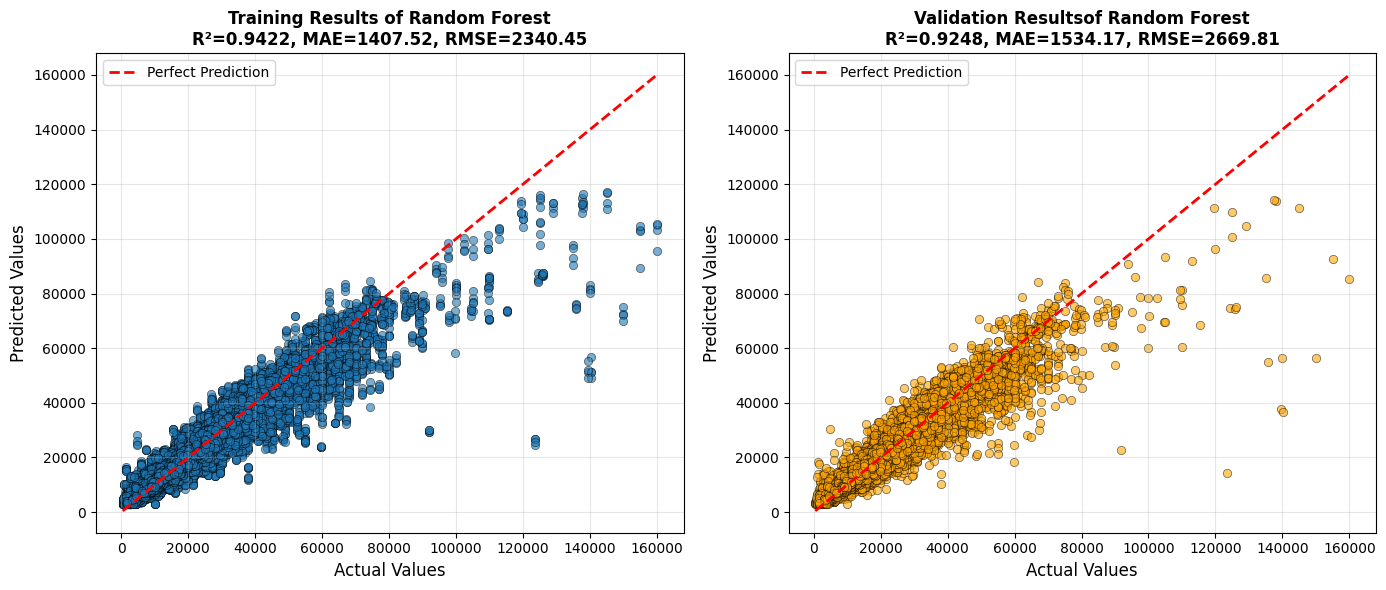

In [57]:
evaluate_best_model_with_cv(RF_tuned, X, y, model_name= "Random Forest", cv=5)

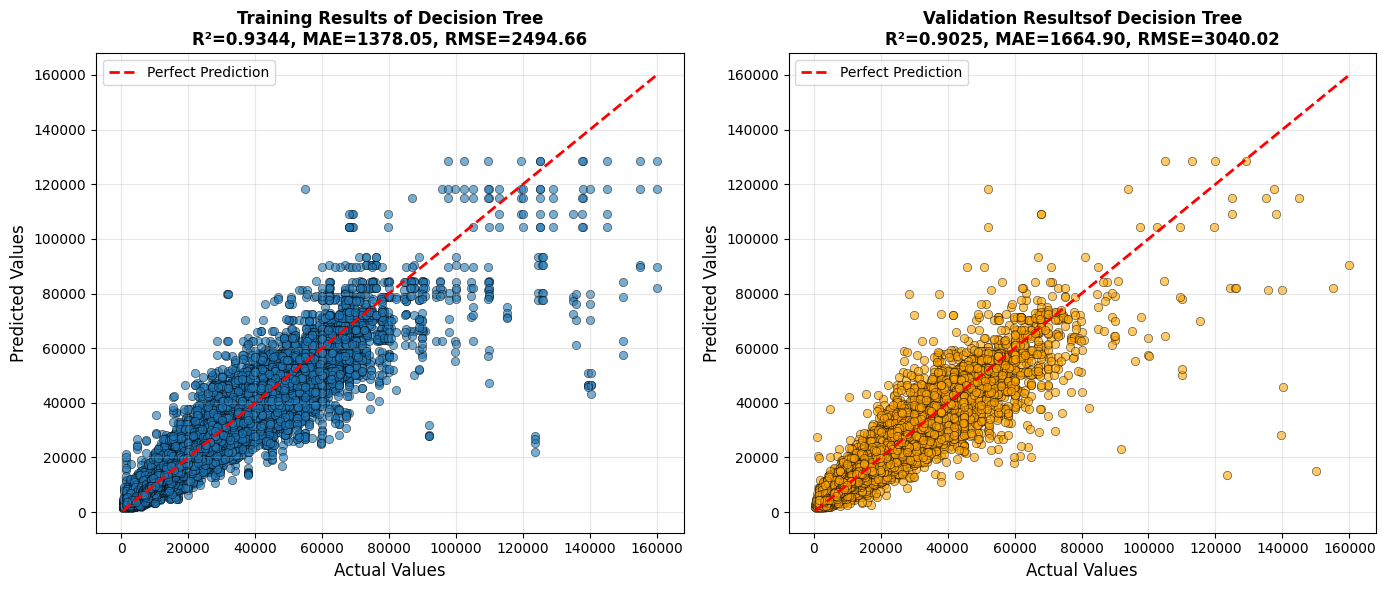

In [58]:
evaluate_best_model_with_cv(DT_tuned, X, y,model_name= "Decision Tree", cv=5)

In [59]:
evaluate_best_model_with_cv(ET_tuned, X, y,model_name= "Extra Trees", cv=5)

KeyboardInterrupt: 

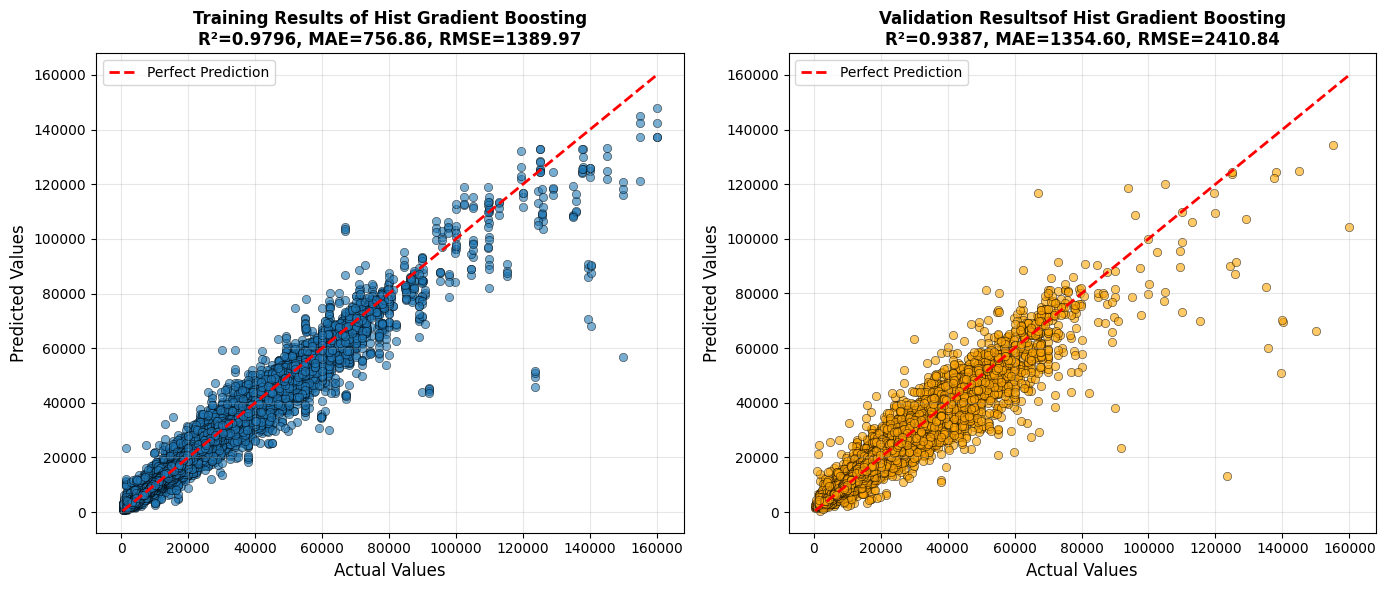

In [60]:
evaluate_best_model_with_cv(HGB_tuned, X, y,model_name= "Hist Gradient Boosting", cv=5)